# Longstaff-Schwartz for Bermudan Put Options

Clean rebuild of the original `LLS_Reg.ipynb` notebook. The goal is to price a Bermudan put option under geometric Brownian motion using Longstaff-Schwartz Monte Carlo, with reusable functions and clear diagnostics.

## 1. Imports and Global Settings

In [89]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Model and Option Parameters

In [90]:
@dataclass(frozen=True)
class BermudanPutParams:
    s0: float = 100.0
    strike: float = 110.0
    maturity: float = 10.0
    risk_free_rate: float = 0.10
    volatility: float = 0.25
    n_paths: int = 100_000
    n_steps: int = 100
    n_exercise_dates: int = 10
    regression_degree: int = 2
    seed: int = 42

    @property
    def dt(self) -> float:
        return self.maturity / self.n_steps


params = BermudanPutParams()
params

BermudanPutParams(s0=100.0, strike=110.0, maturity=10.0, risk_free_rate=0.1, volatility=0.25, n_paths=100000, n_steps=100, n_exercise_dates=10, regression_degree=2, seed=42)

## 3. Simulation Engine

In [91]:
def simulate_gbm_paths(params: BermudanPutParams) -> tuple[np.ndarray, np.ndarray]:
    """Simulate risk-neutral geometric Brownian motion paths."""
    rng = np.random.default_rng(params.seed)
    times = np.linspace(0.0, params.maturity, params.n_steps + 1)
    paths = np.empty((params.n_paths, params.n_steps + 1), dtype=float)
    paths[:, 0] = params.s0

    drift = (params.risk_free_rate - 0.5 * params.volatility**2) * params.dt
    diffusion = params.volatility * np.sqrt(params.dt)

    shocks = rng.standard_normal((params.n_paths, params.n_steps))
    log_returns = drift + diffusion * shocks
    paths[:, 1:] = params.s0 * np.exp(np.cumsum(log_returns, axis=1))

    return times, paths


times, paths = simulate_gbm_paths(params)
paths.shape

(100000, 101)

## 4. Payoff and Exercise Dates

In [92]:
def put_payoff(spot: np.ndarray, strike: float) -> np.ndarray:
    return np.maximum(strike - spot, 0.0)


def bermudan_exercise_indices(params: BermudanPutParams) -> np.ndarray:
    """Return exercise dates on the simulation grid, including maturity."""
    return np.linspace(
        params.n_steps // params.n_exercise_dates,
        params.n_steps,
        params.n_exercise_dates,
        dtype=int,
    )


exercise_indices = bermudan_exercise_indices(params)
exercise_times = times[exercise_indices]
exercise_indices, exercise_times

(array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]))

## 5. Longstaff-Schwartz Bermudan Pricer

In [93]:
def fit_polynomial_continuation(spot: np.ndarray, discounted_value: np.ndarray, degree: int) -> tuple[np.ndarray, LinearRegression, PolynomialFeatures]:
    """Estimate continuation values E[V_next | S_t] using polynomial regression."""
    x = spot.reshape(-1, 1)
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    x_poly = poly.fit_transform(x)
    model = LinearRegression().fit(x_poly, discounted_value)
    continuation = model.predict(x_poly)
    return continuation, model, poly


def price_bermudan_put_lsm(params: BermudanPutParams, paths: np.ndarray) -> dict:
    exercise_indices = bermudan_exercise_indices(params)
    maturity_index = exercise_indices[-1]

    values = put_payoff(paths[:, maturity_index], params.strike)
    exercise_time = np.full(params.n_paths, params.maturity)
    diagnostics = []
    next_index = maturity_index

    for current_index in reversed(exercise_indices[:-1]):
        discount = np.exp(-params.risk_free_rate * (next_index - current_index) * params.dt)
        discounted_values = values * discount

        spot = paths[:, current_index]
        intrinsic = put_payoff(spot, params.strike)
        itm = intrinsic > 0.0

        current_values = discounted_values.copy()

        if np.any(itm):
            continuation, model, poly = fit_polynomial_continuation(
                spot[itm],
                discounted_values[itm],
                params.regression_degree,
            )
            exercise = intrinsic[itm] > continuation
            itm_indices = np.flatnonzero(itm)
            exercise_indices_now = itm_indices[exercise]

            current_values[exercise_indices_now] = intrinsic[exercise_indices_now]
            exercise_time[exercise_indices_now] = current_index * params.dt

            diagnostics.append(
                {
                    "time_index": current_index,
                    "time": current_index * params.dt,
                    "n_itm": int(np.sum(itm)),
                    "n_exercised": int(np.sum(exercise)),
                    "model": model,
                    "poly": poly,
                }
            )

        values = current_values
        next_index = current_index

    initial_discount = np.exp(-params.risk_free_rate * next_index * params.dt)
    price = float(np.mean(values) * initial_discount)
    standard_error = float(np.std(values * initial_discount, ddof=1) / np.sqrt(params.n_paths))

    return {
        "price": price,
        "standard_error": standard_error,
        "exercise_time": exercise_time,
        "diagnostics": diagnostics,
    }


result = price_bermudan_put_lsm(params, paths)
print(f"Bermudan put price: {result['price']:.4f}")
print(f"Monte Carlo standard error: {result['standard_error']:.4f}")

Bermudan put price: 12.9543
Monte Carlo standard error: 0.0414


## 6. Diagnostics

In [94]:
diagnostics_table = [
    (d["time_index"], d["time"], d["n_itm"], d["n_exercised"])
    for d in result["diagnostics"]
]

diagnostics_table[:5]

[(np.int64(90), np.float64(9.0), 24210, 20966),
 (np.int64(80), np.float64(8.0), 26098, 21205),
 (np.int64(70), np.float64(7.0), 27987, 21587),
 (np.int64(60), np.float64(6.0), 30184, 22921),
 (np.int64(50), np.float64(5.0), 32952, 24218)]

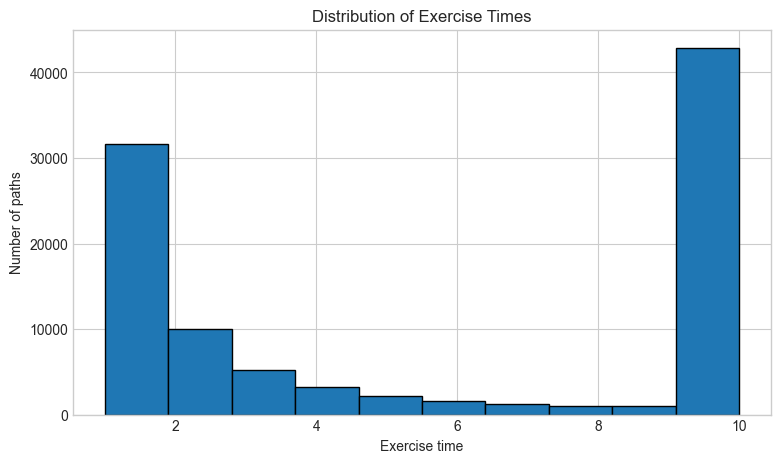

In [95]:
plt.figure(figsize=(9, 5))
plt.hist(result["exercise_time"], bins=params.n_exercise_dates, edgecolor="black")
plt.xlabel("Exercise time")
plt.ylabel("Number of paths")
plt.title("Distribution of Exercise Times")
plt.show()

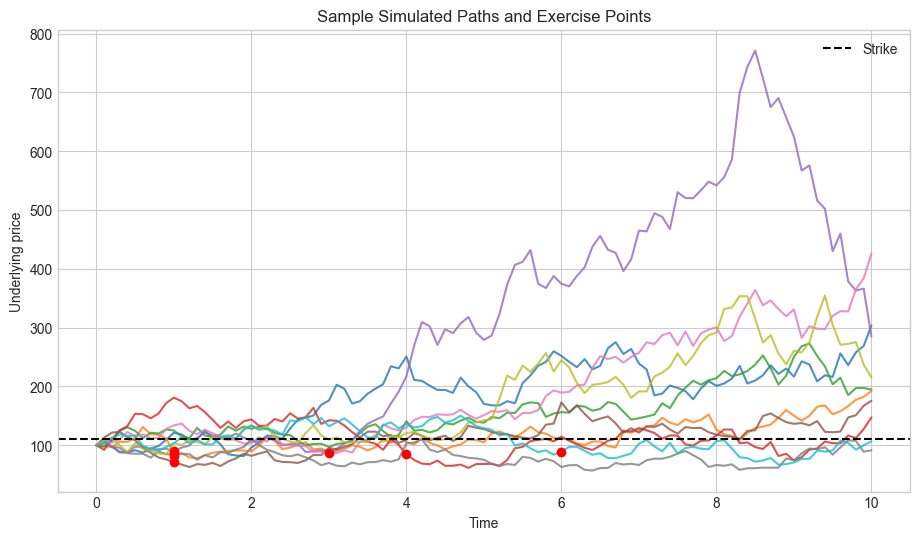

In [96]:
rng = np.random.default_rng(params.seed)
sample_indices = rng.choice(params.n_paths, size=10, replace=False)

plt.figure(figsize=(11, 6))
for path_index in sample_indices:
    plt.plot(times, paths[path_index], alpha=0.8)
    ex_time = result["exercise_time"][path_index]
    if ex_time < params.maturity:
        ex_index = int(round(ex_time / params.dt))
        plt.scatter(ex_time, paths[path_index, ex_index], color="red", zorder=3)

plt.axhline(params.strike, color="black", linestyle="--", label="Strike")
plt.xlabel("Time")
plt.ylabel("Underlying price")
plt.title("Sample Simulated Paths and Exercise Points")
plt.legend()
plt.show()

## 7. Next Improvements

This section turns the improvement checklist into runnable project-quality checks.

### 7.1 Import the Reusable Project Module

In [97]:
import importlib
import sys
from pathlib import Path

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd() / "quant_training" / "LongStaff_Schwartz_Berm_Options",
]
PROJECT_ROOT = next(root for root in candidate_roots if (root / "src" / "lsm_bermudan.py").exists())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import lsm_bermudan

importlib.reload(lsm_bermudan)

from lsm_bermudan import (
    BermudanPutParams,
    american_exercise_indices,
    bermudan_regression_snapshot,
    bermudan_exercise_indices,
    black_scholes_put_price,
    price_american_put_lsm,
    price_bermudan_put_lsm_neural,
    price_bermudan_put_lsm,
    price_put_lsm,
    simulate_gbm_paths,
)

### 7.2 European vs Bermudan vs American Put

In [98]:
comparison_params = BermudanPutParams(
    s0=params.s0,
    strike=params.strike,
    maturity=params.maturity,
    risk_free_rate=params.risk_free_rate,
    volatility=params.volatility,
    n_paths=params.n_paths,
    n_steps=params.n_steps,
    n_exercise_dates=params.n_exercise_dates,
    regression_degree=params.regression_degree,
    seed=params.seed,
)

comparison_times, comparison_paths = simulate_gbm_paths(comparison_params)
european_price = black_scholes_put_price(comparison_params)
bermudan_result = price_bermudan_put_lsm(comparison_params, comparison_paths)
american_result = price_american_put_lsm(comparison_params, comparison_paths)

price_comparison = {
    "European Black-Scholes": european_price,
    "Bermudan LSM": bermudan_result["price"],
    "American LSM": american_result["price"],
}

price_comparison

{'European Black-Scholes': 2.999793177914337,
 'Bermudan LSM': 12.954313729542234,
 'American LSM': 14.541037123081445}

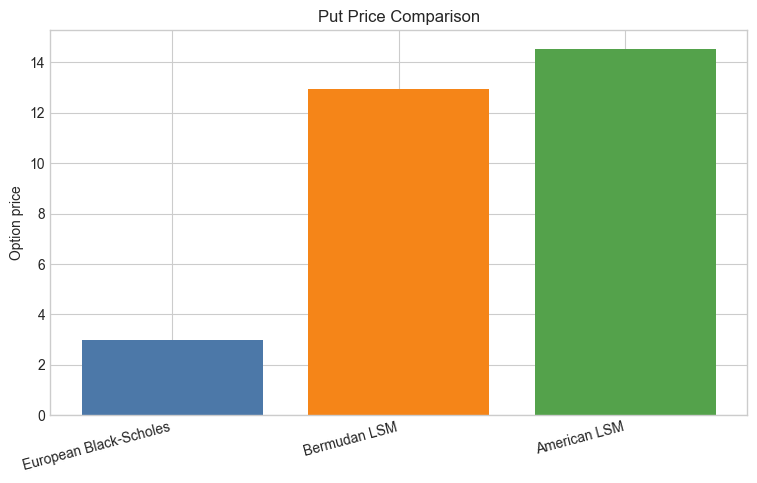

Bermudan standard error: 0.0414
American standard error: 0.0376


In [99]:
labels = list(price_comparison.keys())
prices = list(price_comparison.values())

plt.figure(figsize=(9, 5))
plt.bar(labels, prices, color=["#4c78a8", "#f58518", "#54a24b"])
plt.ylabel("Option price")
plt.title("Put Price Comparison")
plt.xticks(rotation=15, ha="right")
plt.show()

print(f"Bermudan standard error: {bermudan_result['standard_error']:.4f}")
print(f"American standard error: {american_result['standard_error']:.4f}")

### 7.3 Payoff Plots by Method

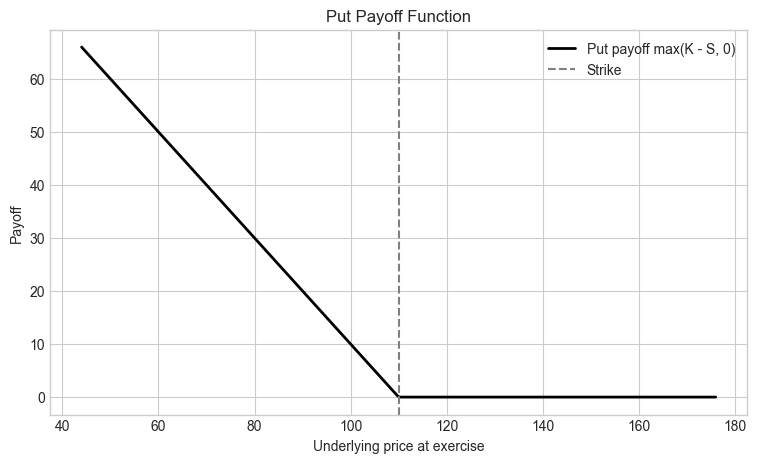

In [100]:
spot_grid = np.linspace(0.4 * params.strike, 1.6 * params.strike, 300)
terminal_put_payoff = put_payoff(spot_grid, params.strike)

plt.figure(figsize=(9, 5))
plt.plot(spot_grid, terminal_put_payoff, color="black", lw=2, label="Put payoff max(K - S, 0)")
plt.axvline(params.strike, color="gray", linestyle="--", label="Strike")
plt.xlabel("Underlying price at exercise")
plt.ylabel("Payoff")
plt.title("Put Payoff Function")
plt.legend()
plt.show()

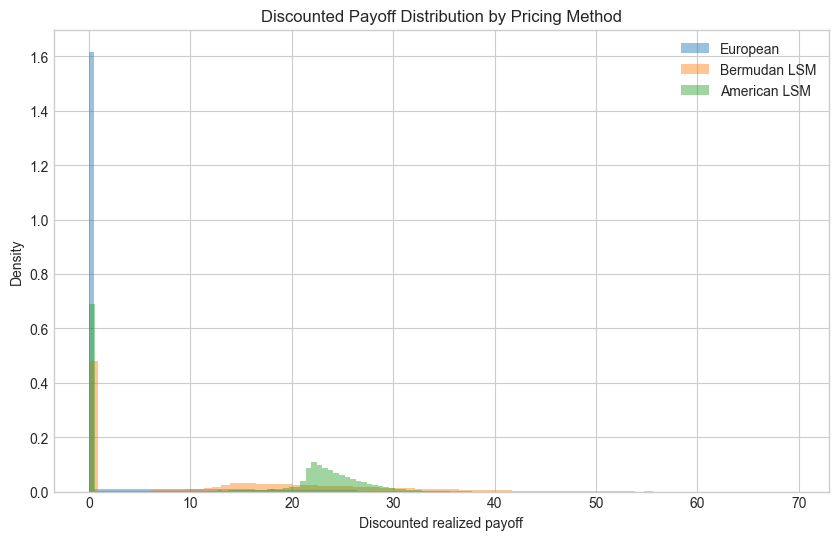

In [101]:
european_discounted_payoffs = (
    put_payoff(comparison_paths[:, -1], comparison_params.strike)
    * np.exp(-comparison_params.risk_free_rate * comparison_params.maturity)
)

payoff_samples = {
    "European": european_discounted_payoffs,
    "Bermudan LSM": bermudan_result["discounted_path_values"],
    "American LSM": american_result["discounted_path_values"],
}

plt.figure(figsize=(10, 6))
for label, sample in payoff_samples.items():
    plt.hist(sample, bins=80, density=True, alpha=0.45, label=label)

plt.xlabel("Discounted realized payoff")
plt.ylabel("Density")
plt.title("Discounted Payoff Distribution by Pricing Method")
plt.legend()
plt.show()

In [102]:
payoff_summary = {
    label: {
        "mean": float(np.mean(sample)),
        "std": float(np.std(sample, ddof=1)),
        "p05": float(np.percentile(sample, 5)),
        "p50": float(np.percentile(sample, 50)),
        "p95": float(np.percentile(sample, 95)),
    }
    for label, sample in payoff_samples.items()
}

payoff_summary

{'European': {'mean': 3.005414347664498,
  'std': 6.896429220421612,
  'p05': 0.0,
  'p50': 0.0,
  'p95': 20.69280009212492},
 'Bermudan LSM': {'mean': 12.954313729542234,
  'std': 13.087281929747247,
  'p05': 0.0,
  'p50': 13.497556694282576,
  'p95': 36.397051629486555},
 'American LSM': {'mean': 14.541037123081445,
  'std': 11.88665686974193,
  'p05': 0.0,
  'p50': 21.481022152814624,
  'p95': 28.900161020371947}}

Expected ordering for a non-dividend-paying put is usually: European <= Bermudan <= American. Small Monte Carlo noise can make the estimates slightly violate this, especially with few paths or unstable regressions.

### 7.4 Continuation Regression Plot

This is the core Longstaff-Schwartz diagnostic: each point is a simulated discounted future payoff at an exercise date, and the red curve is the fitted continuation value.

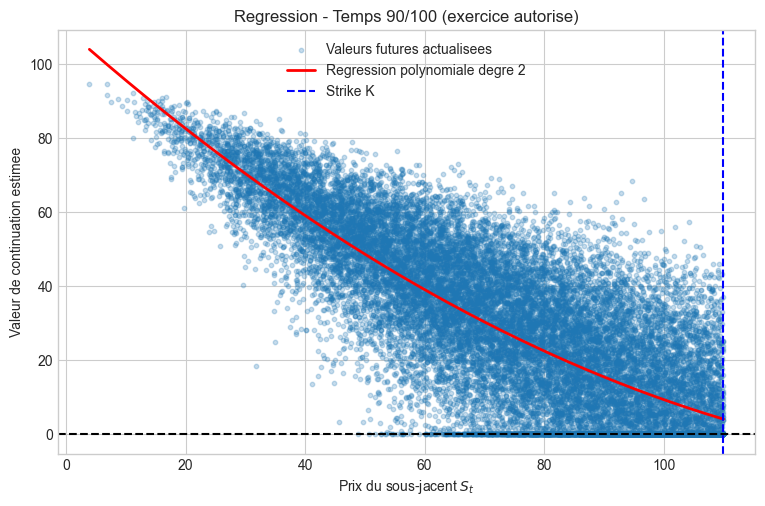

In [103]:
snapshot_index = int(bermudan_exercise_indices(comparison_params)[-2])
snapshot = bermudan_regression_snapshot(comparison_params, comparison_paths, target_index=snapshot_index)

x = snapshot["spot_itm"]
y = snapshot["discounted_values_itm"]
model = snapshot["model"]
poly = snapshot["poly"]

x_plot = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_plot = model.predict(poly.transform(x_plot))

plt.figure(figsize=(9, 5.5))
plt.scatter(x, y, alpha=0.25, s=10, label="Valeurs futures actualisees")
plt.plot(x_plot, y_plot, color="red", lw=2, label=f"Regression polynomiale degre {comparison_params.regression_degree}")
plt.axvline(comparison_params.strike, color="blue", linestyle="--", lw=1.5, label="Strike K")
plt.axhline(0, color="black", linestyle="--", lw=1.5)
plt.xlabel(r"Prix du sous-jacent $S_t$")
plt.ylabel("Valeur de continuation estimee")
plt.title(f"Regression - Temps {snapshot['time_index']}/{comparison_params.n_steps} (exercice autorise)")
plt.legend()
plt.grid(True)
plt.show()

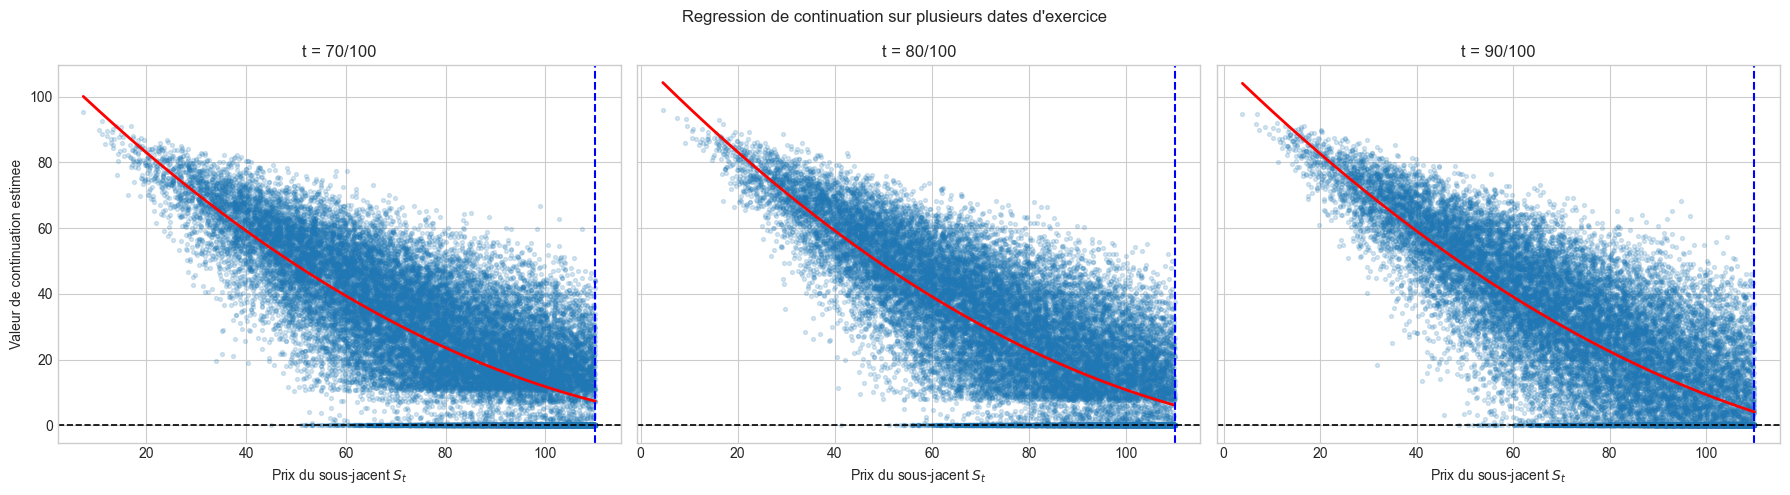

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
selected_indices = bermudan_exercise_indices(comparison_params)[-4:-1]

for ax, idx in zip(axes, selected_indices):
    snap = bermudan_regression_snapshot(comparison_params, comparison_paths, target_index=int(idx))
    x = snap["spot_itm"]
    y = snap["discounted_values_itm"]
    x_plot = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
    y_plot = snap["model"].predict(snap["poly"].transform(x_plot))

    ax.scatter(x, y, alpha=0.18, s=8)
    ax.plot(x_plot, y_plot, color="red", lw=2)
    ax.axvline(comparison_params.strike, color="blue", linestyle="--", lw=1.5)
    ax.axhline(0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"t = {snap['time_index']}/{comparison_params.n_steps}")
    ax.set_xlabel(r"Prix du sous-jacent $S_t$")
    ax.grid(True)

axes[0].set_ylabel("Valeur de continuation estimee")
fig.suptitle("Regression de continuation sur plusieurs dates d'exercice")
plt.tight_layout()
plt.show()

### 7.5 Convergence Checks

In [105]:
def run_bermudan_experiment(n_paths: int, degree: int, n_exercise_dates: int, seed: int = 42) -> dict:
    experiment_params = BermudanPutParams(
        s0=params.s0,
        strike=params.strike,
        maturity=params.maturity,
        risk_free_rate=params.risk_free_rate,
        volatility=params.volatility,
        n_paths=n_paths,
        n_steps=params.n_steps,
        n_exercise_dates=n_exercise_dates,
        regression_degree=degree,
        seed=seed,
    )
    _, experiment_paths = simulate_gbm_paths(experiment_params)
    experiment_result = price_bermudan_put_lsm(experiment_params, experiment_paths)
    return {
        "n_paths": n_paths,
        "degree": degree,
        "n_exercise_dates": n_exercise_dates,
        "price": experiment_result["price"],
        "standard_error": experiment_result["standard_error"],
    }


convergence_results = []

for n_paths in [10_000, 25_000, 50_000]:
    convergence_results.append(run_bermudan_experiment(n_paths, degree=2, n_exercise_dates=10))

for degree in [1, 2, 3, 4]:
    convergence_results.append(run_bermudan_experiment(25_000, degree=degree, n_exercise_dates=10))

for n_exercise_dates in [5, 10, 20, 50]:
    convergence_results.append(run_bermudan_experiment(25_000, degree=2, n_exercise_dates=n_exercise_dates))

convergence_results

[{'n_paths': 10000,
  'degree': 2,
  'n_exercise_dates': 10,
  'price': 13.004851660676147,
  'standard_error': 0.13035496240061034},
 {'n_paths': 25000,
  'degree': 2,
  'n_exercise_dates': 10,
  'price': 13.056329769351803,
  'standard_error': 0.08234455608490691},
 {'n_paths': 50000,
  'degree': 2,
  'n_exercise_dates': 10,
  'price': 12.986352211917373,
  'standard_error': 0.0584978486372948},
 {'n_paths': 25000,
  'degree': 1,
  'n_exercise_dates': 10,
  'price': 13.021519247881583,
  'standard_error': 0.08359027659489117},
 {'n_paths': 25000,
  'degree': 2,
  'n_exercise_dates': 10,
  'price': 13.056329769351803,
  'standard_error': 0.08234455608490691},
 {'n_paths': 25000,
  'degree': 3,
  'n_exercise_dates': 10,
  'price': 13.056310090965079,
  'standard_error': 0.08196139393781893},
 {'n_paths': 25000,
  'degree': 4,
  'n_exercise_dates': 10,
  'price': 13.057637173489454,
  'standard_error': 0.08216136330919807},
 {'n_paths': 25000,
  'degree': 2,
  'n_exercise_dates': 5,
  '

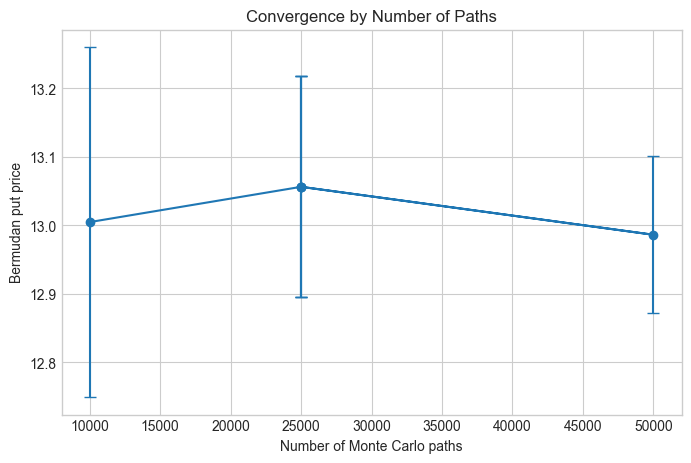

In [106]:
path_sweep = [row for row in convergence_results if row["degree"] == 2 and row["n_exercise_dates"] == 10]

plt.figure(figsize=(8, 5))
plt.errorbar(
    [row["n_paths"] for row in path_sweep],
    [row["price"] for row in path_sweep],
    yerr=[1.96 * row["standard_error"] for row in path_sweep],
    marker="o",
    capsize=4,
)
plt.xlabel("Number of Monte Carlo paths")
plt.ylabel("Bermudan put price")
plt.title("Convergence by Number of Paths")
plt.show()

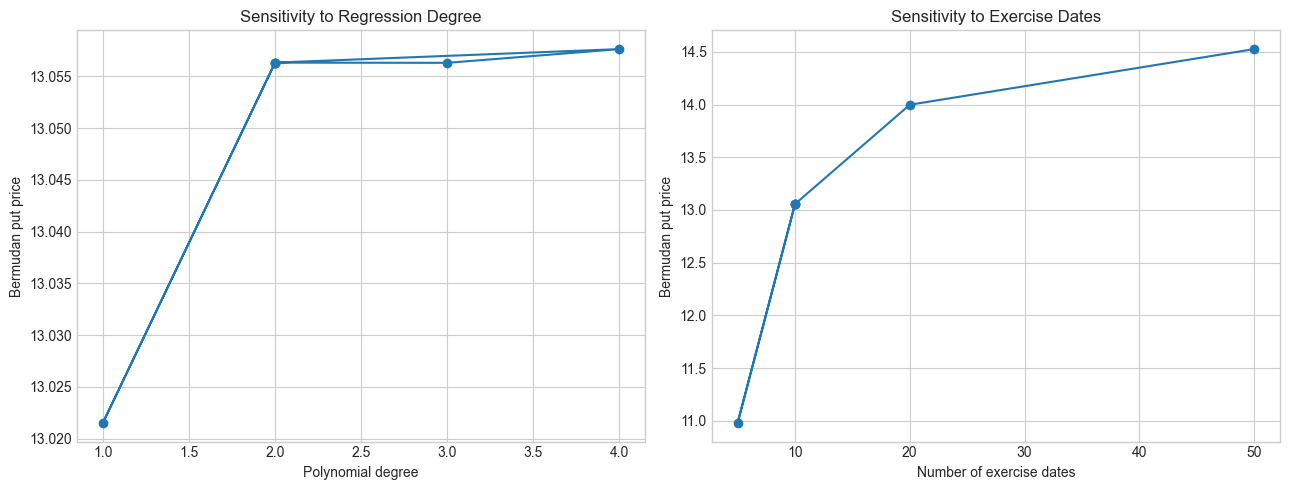

In [107]:
degree_sweep = [row for row in convergence_results if row["n_paths"] == 25_000 and row["n_exercise_dates"] == 10]
exercise_sweep = [row for row in convergence_results if row["n_paths"] == 25_000 and row["degree"] == 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot([row["degree"] for row in degree_sweep], [row["price"] for row in degree_sweep], marker="o")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Bermudan put price")
axes[0].set_title("Sensitivity to Regression Degree")

axes[1].plot([row["n_exercise_dates"] for row in exercise_sweep], [row["price"] for row in exercise_sweep], marker="o")
axes[1].set_xlabel("Number of exercise dates")
axes[1].set_ylabel("Bermudan put price")
axes[1].set_title("Sensitivity to Exercise Dates")

plt.tight_layout()
plt.show()

### 7.6 Neural-Network Continuation Regression

The original notebook tested neural-network continuation regression. Here we keep it as an extension, not the baseline: the neural model uses the same simulated paths and exercise dates as the polynomial LSM pricer, so the comparison is clean.

In [108]:
nn_params = BermudanPutParams(
    s0=params.s0,
    strike=params.strike,
    maturity=params.maturity,
    risk_free_rate=params.risk_free_rate,
    volatility=params.volatility,
    n_paths=25_000,
    n_steps=params.n_steps,
    n_exercise_dates=params.n_exercise_dates,
    regression_degree=params.regression_degree,
    seed=params.seed,
)

nn_times, nn_paths = simulate_gbm_paths(nn_params)
poly_nn_baseline = price_bermudan_put_lsm(nn_params, nn_paths)
neural_result = price_bermudan_put_lsm_neural(
    nn_params,
    nn_paths,
    hidden_layer_sizes=(32, 16),
    max_iter=500,
)

nn_comparison = {
    "Polynomial LSM": poly_nn_baseline["price"],
    "Neural LSM": neural_result["price"],
}

nn_comparison

{'Polynomial LSM': 13.056329769351803, 'Neural LSM': 13.05174769263719}

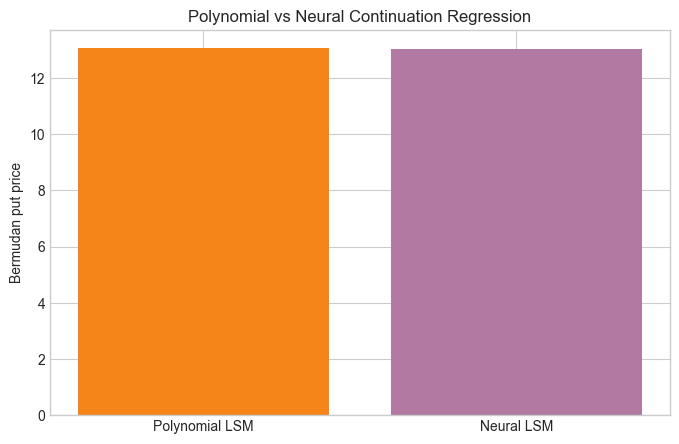

Polynomial LSM: 13.0563 +/- 0.1614
Neural LSM: 13.0517 +/- 0.1603


In [109]:
plt.figure(figsize=(8, 5))
plt.bar(nn_comparison.keys(), nn_comparison.values(), color=["#f58518", "#b279a2"])
plt.ylabel("Bermudan put price")
plt.title("Polynomial vs Neural Continuation Regression")
plt.show()

print(f"Polynomial LSM: {poly_nn_baseline['price']:.4f} +/- {1.96 * poly_nn_baseline['standard_error']:.4f}")
print(f"Neural LSM: {neural_result['price']:.4f} +/- {1.96 * neural_result['standard_error']:.4f}")

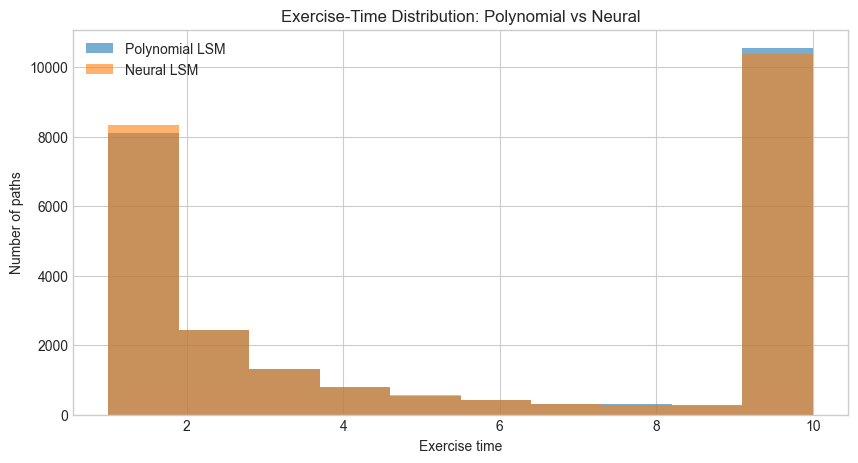

In [110]:
plt.figure(figsize=(10, 5))
plt.hist(poly_nn_baseline["exercise_time"], bins=nn_params.n_exercise_dates, alpha=0.6, label="Polynomial LSM")
plt.hist(neural_result["exercise_time"], bins=nn_params.n_exercise_dates, alpha=0.6, label="Neural LSM")
plt.xlabel("Exercise time")
plt.ylabel("Number of paths")
plt.title("Exercise-Time Distribution: Polynomial vs Neural")
plt.legend()
plt.show()

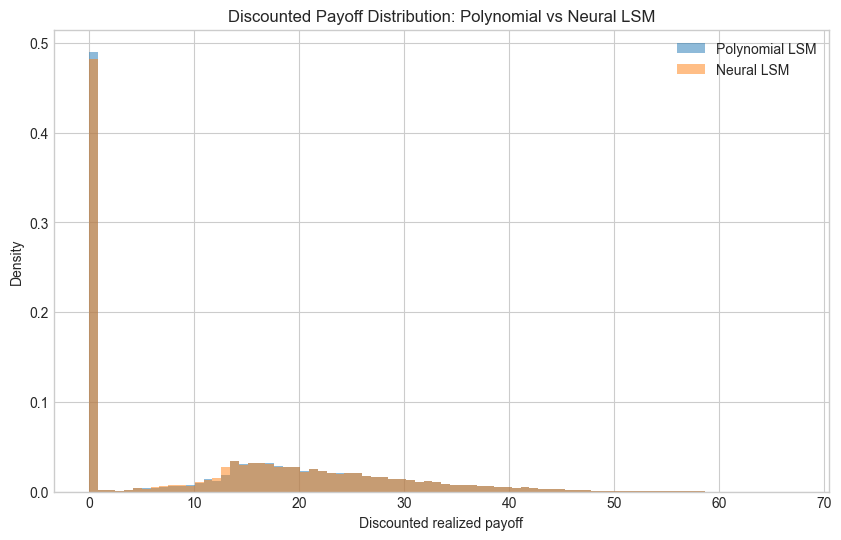

{'Polynomial LSM': 13.056329769351803, 'Neural LSM': 13.05174769263719}

In [111]:
neural_payoff_samples = {
    "Polynomial LSM": poly_nn_baseline["discounted_path_values"],
    "Neural LSM": neural_result["discounted_path_values"],
}

plt.figure(figsize=(10, 6))
for label, sample in neural_payoff_samples.items():
    plt.hist(sample, bins=80, density=True, alpha=0.5, label=label)

plt.xlabel("Discounted realized payoff")
plt.ylabel("Density")
plt.title("Discounted Payoff Distribution: Polynomial vs Neural LSM")
plt.legend()
plt.show()

{label: float(np.mean(sample)) for label, sample in neural_payoff_samples.items()}

Neural regression is more flexible, but it is also slower and more sensitive to architecture, scaling, and random initialization. In this one-factor GBM example, a low-degree polynomial is often already strong; the neural version becomes more interesting for higher-dimensional state variables or path-dependent features.